# MNIST digit recognition — a from-scratch walkthrough

Goal: understand every piece of a neural network by building one to recognise handwritten digits (0-9) from the classic MNIST dataset.

We'll go in stages:
1. Load and look at the data
2. Build the simplest possible model (fully-connected)
3. Write the training loop by hand
4. Evaluate — accuracy, confusion matrix, look at mistakes
5. Upgrade to a small CNN and compare

Run each cell in order (Shift+Enter). Read the markdown notes between cells — they explain *why*, not just *what*.

## 1. Load and explore the data

MNIST is 70,000 grayscale images of handwritten digits, each 28x28 pixels: 60,000 for training, 10,000 held out for testing.

`torchvision.datasets.MNIST` downloads it automatically the first time you run this.

In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

torch.manual_seed(0)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)


Using device: cpu


In [2]:
# ToTensor() converts a PIL image (0-255 ints) to a float tensor in [0, 1], shape (1, 28, 28)
transform = transforms.ToTensor()

train_data = datasets.MNIST(root="data", train=True, download=True, transform=transform)
test_data = datasets.MNIST(root="data", train=False, download=True, transform=transform)

print(f"Training examples: {len(train_data)}")
print(f"Test examples: {len(test_data)}")
print(f"Image shape: {train_data[0][0].shape}")  # (channels, height, width)

Training examples: 60000
Test examples: 10000
Image shape: torch.Size([1, 28, 28])


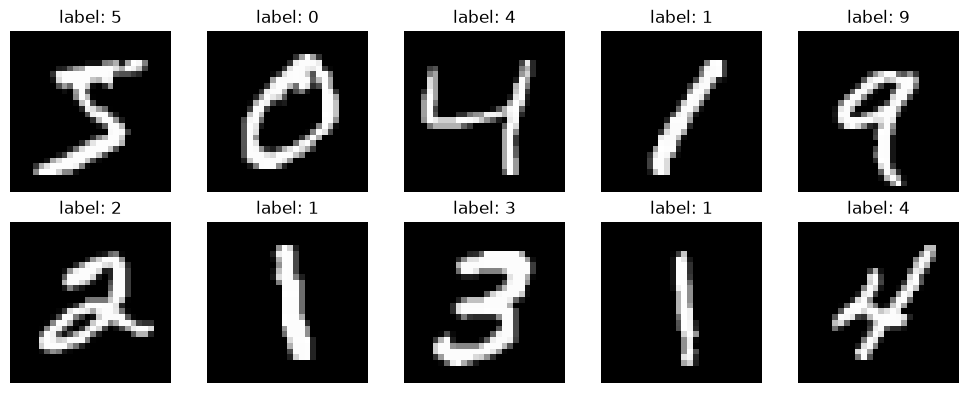

In [3]:
# Look at some actual images before doing anything else — build intuition for what the model will see.
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    image, label = train_data[i]
    ax.imshow(image.squeeze(), cmap="gray")
    ax.set_title(f"label: {label}")
    ax.axis("off")
plt.tight_layout()
plt.show()

`DataLoader` wraps a dataset and hands it to the training loop in shuffled mini-batches. Instead of computing the loss on all 60,000 images at once (slow, memory-heavy) or one at a time (noisy, also slow), we process e.g. 64 images per step.

In [4]:
batch_size = 64
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

images, labels = next(iter(train_loader))
print("Batch of images:", images.shape)  # (batch_size, 1, 28, 28)
print("Batch of labels:", labels.shape)

Batch of images: torch.Size([64, 1, 28, 28])
Batch of labels: torch.Size([64])


## 2. Build the simplest possible model

A feedforward (fully-connected) network — no convolutions yet, deliberately, so every operation is easy to reason about:

1. **Flatten**: turn each 28x28 image into a single vector of 784 numbers.
2. **Linear layer**: `784 -> 128` — each of the 128 output neurons is a weighted sum of all 784 input pixels, plus a bias. The weights are what the network *learns*.
3. **ReLU**: a nonlinearity (`max(0, x)`). Without this, stacking linear layers would collapse into a single linear layer — the nonlinearity is what lets the network learn non-linear patterns like "digit shapes".
4. **Linear layer**: `128 -> 10` — one output per digit class (0-9). The highest value is the model's prediction.

In [5]:
class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.layers = nn.Sequential(
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.layers(x)

model = SimpleNet().to(device)
print(model)

n_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal learnable parameters: {n_params:,}")

SimpleNet(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (layers): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=10, bias=True)
  )
)

Total learnable parameters: 101,770


## 3. The training loop

This is the core loop every neural network training script runs, written out explicitly (not hidden behind a `.fit()` call) so each step is visible:

1. **Forward pass**: feed a batch of images through the model to get predictions.
2. **Loss**: measure how wrong the predictions were (`CrossEntropyLoss` for classification).
3. **Backward pass**: `loss.backward()` computes the gradient of the loss with respect to every weight — i.e. "which direction should each weight move to reduce the error".
4. **Optimizer step**: `optimizer.step()` nudges every weight a small amount in that direction.
5. Repeat for every batch, for several passes ("epochs") over the training data.

In [6]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def train_one_epoch(model, loader, loss_fn, optimizer):
    model.train()
    total_loss = 0.0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        predictions = model(images)
        loss = loss_fn(predictions, labels)

        optimizer.zero_grad()  # clear gradients from the previous step
        loss.backward()        # compute new gradients
        optimizer.step()       # update weights

        total_loss += loss.item() * images.size(0)
    return total_loss / len(loader.dataset)

def evaluate(model, loader, loss_fn):
    model.eval()
    total_loss, correct = 0.0, 0
    with torch.no_grad():  # no need to track gradients when just evaluating
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            predictions = model(images)
            loss = loss_fn(predictions, labels)
            total_loss += loss.item() * images.size(0)
            correct += (predictions.argmax(dim=1) == labels).sum().item()
    avg_loss = total_loss / len(loader.dataset)
    accuracy = correct / len(loader.dataset)
    return avg_loss, accuracy

In [7]:
epochs = 5
for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(model, train_loader, loss_fn, optimizer)
    test_loss, test_acc = evaluate(model, test_loader, loss_fn)
    print(f"Epoch {epoch}: train_loss={train_loss:.4f}  test_loss={test_loss:.4f}  test_acc={test_acc:.4%}")

Epoch 1: train_loss=0.3443  test_loss=0.1935  test_acc=94.4700%
Epoch 2: train_loss=0.1635  test_loss=0.1349  test_acc=96.0200%
Epoch 3: train_loss=0.1137  test_loss=0.1145  test_acc=96.6100%
Epoch 4: train_loss=0.0871  test_loss=0.0937  test_acc=97.3600%
Epoch 5: train_loss=0.0692  test_loss=0.0816  test_acc=97.5700%


## 4. Evaluate more closely

Accuracy alone hides *which* digits get confused for which. A confusion matrix and a look at actual mistakes builds much better intuition.

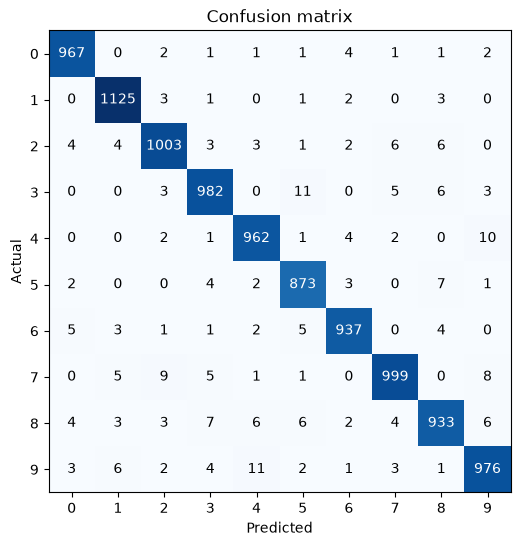

In [8]:
import numpy as np

model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        preds = model(images).argmax(dim=1).cpu()
        all_preds.append(preds)
        all_labels.append(labels)
all_preds = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

confusion = np.zeros((10, 10), dtype=int)
for true, pred in zip(all_labels, all_preds):
    confusion[true, pred] += 1

fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(confusion, cmap="Blues")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_xticks(range(10)); ax.set_yticks(range(10))
for i in range(10):
    for j in range(10):
        ax.text(j, i, confusion[i, j], ha="center", va="center",
                 color="white" if confusion[i, j] > confusion.max() / 2 else "black")
plt.title("Confusion matrix")
plt.show()

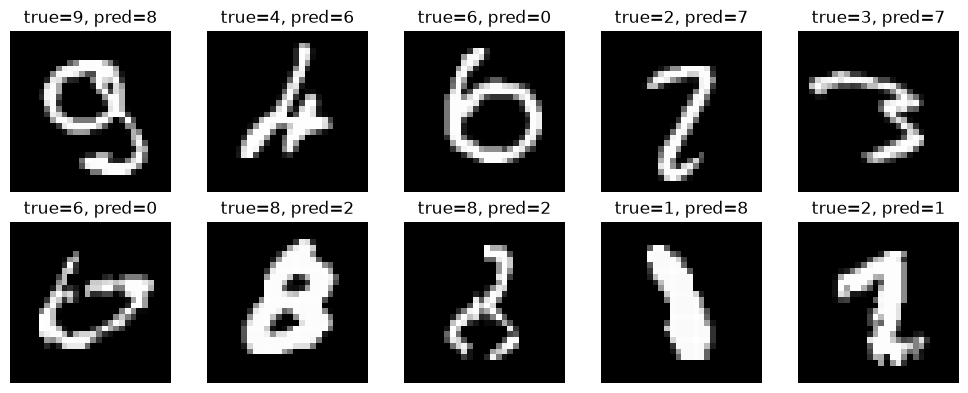

In [9]:
# Look at some actual mistakes
wrong_idx = np.where(all_preds != all_labels)[0][:10]

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for idx, ax in zip(wrong_idx, axes.flat):
    image, true_label = test_data[idx]
    ax.imshow(image.squeeze(), cmap="gray")
    ax.set_title(f"true={true_label}, pred={all_preds[idx]}")
    ax.axis("off")
plt.tight_layout()
plt.show()

## 5. Upgrade to a CNN

The fully-connected model treats pixels as an unordered list of 784 numbers — it has no notion that nearby pixels are related. A **convolutional** layer instead slides small learned filters (e.g. 3x3) across the image, so it can learn local patterns (edges, curves) that appear anywhere in the image. This is the same core building block used for image classification in the map digitiser project's legend/symbol work.

Architecture: `Conv -> ReLU -> Conv -> ReLU -> MaxPool -> Flatten -> Linear -> 10 classes`.

In [10]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),  # 1 input channel (grayscale) -> 16 filters
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 28x28 -> 14x14, keeps the strongest signal in each 2x2 block
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 14 * 14, 10),
        )

    def forward(self, x):
        x = self.conv_layers(x)
        return self.classifier(x)

cnn_model = SimpleCNN().to(device)
cnn_optimizer = torch.optim.Adam(cnn_model.parameters(), lr=1e-3)

n_params = sum(p.numel() for p in cnn_model.parameters())
print(f"Total learnable parameters: {n_params:,}")

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(cnn_model, train_loader, loss_fn, cnn_optimizer)
    test_loss, test_acc = evaluate(cnn_model, test_loader, loss_fn)
    print(f"Epoch {epoch}: train_loss={train_loss:.4f}  test_loss={test_loss:.4f}  test_acc={test_acc:.4%}")

Total learnable parameters: 67,530
Epoch 1: train_loss=0.1883  test_loss=0.0709  test_acc=97.5400%
Epoch 2: train_loss=0.0585  test_loss=0.0485  test_acc=98.4900%
Epoch 3: train_loss=0.0428  test_loss=0.0464  test_acc=98.5200%
Epoch 4: train_loss=0.0338  test_loss=0.0421  test_acc=98.5500%
Epoch 5: train_loss=0.0275  test_loss=0.0358  test_acc=98.7800%


## 6. Test it yourself — draw a digit

Everything so far has only been tested on MNIST's own test images — digits that are already clean, centered, and formatted exactly like the training data. Drawing your own digit is a real test of whether the model **generalizes**, not just whether it memorized this dataset's particular style.

First, save the trained CNN's weights — this is the standard last step of training: persist what was learned so it can be reused without retraining from scratch.

In [11]:
torch.save(cnn_model.state_dict(), "mnist_cnn_weights.pt")
print("Saved trained weights to mnist_cnn_weights.pt")

Saved trained weights to mnist_cnn_weights.pt


Now draw a digit below (click and drag with your mouse), then click **Predict**.

Behind the scenes, your drawing has to be converted into the exact format the model was trained on: resized to 28x28 pixels, converted to grayscale, and color-inverted (MNIST digits are white strokes on a black background, but drawing black-on-white is more natural). This conversion step is exactly the kind of preprocessing mismatch that trips up real-world ML systems — if the model gets your handwriting wrong, this mismatch is often *why*, not because the model is bad.

In [12]:
import ipywidgets as widgets
from ipycanvas import Canvas
from PIL import Image
from IPython.display import display

CANVAS_SIZE = 280  # drawn large for comfort, downscaled to 28x28 before feeding the model

canvas = Canvas(width=CANVAS_SIZE, height=CANVAS_SIZE, sync_image_data=True)
canvas.fill_style = "white"
canvas.fill_rect(0, 0, CANVAS_SIZE, CANVAS_SIZE)
canvas.stroke_style = "black"
canvas.line_width = 18

_drawing = {"active": False}

def _on_mouse_down(x, y):
    _drawing["active"] = True
    canvas.begin_path()
    canvas.move_to(x, y)

def _on_mouse_move(x, y):
    if _drawing["active"]:
        canvas.line_to(x, y)
        canvas.stroke()
        canvas.begin_path()
        canvas.move_to(x, y)

def _on_mouse_up(x, y):
    _drawing["active"] = False

canvas.on_mouse_down(_on_mouse_down)
canvas.on_mouse_move(_on_mouse_move)
canvas.on_mouse_up(_on_mouse_up)

clear_button = widgets.Button(description="Clear")
predict_button = widgets.Button(description="Predict", button_style="primary")
output = widgets.Output()

def _clear_canvas(_):
    canvas.fill_style = "white"
    canvas.fill_rect(0, 0, CANVAS_SIZE, CANVAS_SIZE)
    output.clear_output()

def _predict_digit(_):
    output.clear_output()
    arr = canvas.get_image_data()  # (H, W, 4) RGBA uint8, captured from your drawing
    img = Image.fromarray(arr[:, :, :3], mode="RGB").convert("L").resize((28, 28), Image.LANCZOS)
    pixels = 255 - np.array(img)  # invert: MNIST is white-on-black, we drew black-on-white

    tensor = torch.tensor(pixels, dtype=torch.float32).div(255.0)
    tensor = tensor.unsqueeze(0).unsqueeze(0).to(device)  # (1, 1, 28, 28)

    cnn_model.eval()
    with torch.no_grad():
        logits = cnn_model(tensor)
        probs = torch.softmax(logits, dim=1).squeeze().cpu().numpy()
    predicted = int(probs.argmax())

    with output:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3))
        ax1.imshow(pixels, cmap="gray")
        ax1.set_title(f"Model sees this, predicts: {predicted}")
        ax1.axis("off")
        ax2.bar(range(10), probs)
        ax2.set_xticks(range(10))
        ax2.set_xlabel("Digit")
        ax2.set_ylabel("Confidence")
        plt.tight_layout()
        plt.show()

clear_button.on_click(_clear_canvas)
predict_button.on_click(_predict_digit)

display(widgets.HTML("<b>Draw a digit (click and drag), then click Predict:</b>"))
display(canvas)
display(widgets.HBox([clear_button, predict_button]))
display(output)

HTML(value='<b>Draw a digit (click and drag), then click Predict:</b>')

Canvas(height=280, sync_image_data=True, width=280)

Output()

## 7. Compare and reflect

- Which model got higher test accuracy — the fully-connected net or the CNN?
- Look back at the confusion matrix and mistakes from the fully-connected model — re-run that analysis (cells above) with `cnn_model` swapped in and see if the *same* digits are still confused.

### Ideas to experiment with next
- Change `lr` (learning rate) — try `1e-2` or `1e-4`, see how training changes.
- Add `nn.Dropout(0.25)` between layers — does it help or hurt on this dataset?
- Change the number of epochs — does accuracy keep improving, or plateau/overfit?
- Try a wrong-image case and think about *why* a human would also find it ambiguous.